In [1]:
# clean single cell data in preparation for metacell
import anndata as ad             
import matplotlib.pyplot as plt  
import metacells as mc         
import numpy as np               
import seaborn as sb                                 
from typing import *

/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/google_crc32c/__init__.py:29: RuntimeWarning: As the c extension couldn't be imported, `google-crc32c` is using a pure python implementation that is significantly slower. If possible, please configure a c build environment and compile the extension
  warnings.warn(_SLOW_CRC32C_WARNING, RuntimeWarning)


In [3]:
# constants
DATASET_NAME = 'hbca'
OUTPUT_DIR = 'metacell_clean/'
DATASET_DIR = '/media/ResearchHome/plummgrp/home/common/Maggie/QuantumCell/cellxgene/'

# genes to explicitly exclude
EXCLUDED_GENE_NAMES = ['XIST', 'MALAT1']  # Sex-specific genes.
EXCLUDED_GENE_PATTERNS = ['MT-.*']        # Mitochondrial.

In [4]:
# get original data downloaded from cellxgene
full = ad.read_h5ad(DATASET_DIR + DATASET_NAME + '.h5ad')
full

AnnData object with n_obs × n_vars = 117346 × 32383
    obs: 'mapped_reference_assembly', 'mapped_reference_annotation', 'alignment_software', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'donor_living_at_sample_collection', 'donor_menopausal_status', 'sample_uuid', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_derivation_process', 'sample_source', 'donor_BMI_at_collection', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_uuid', 'suspension_type', 'library_uuid', 'assay_ontology_term_id', 'library_starting_quantity', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'sex_ontology_term_id', 'procedure_group', 'tissue_location', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'sample_id', 'age_group', 'bmi_group', 'breast_density', 'tissue_type', 'reported_diseases', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_

In [5]:
# make sure data is float32 (metacell requires this)
full.X = full.X.astype(np.float32)

In [5]:
# if filtering for disease
disease = 'myeloid leukemia'
full = full[full.obs['disease'] == disease]
DATASET_NAME = 'aml' # if it needs to be different from original dataset name (e.g. bone marrow -> aml)

In [6]:
# if filtering for normal
full = full[full.obs['disease'] == 'normal']

In [7]:
# remove unknown/NA cell types
full = full[full.obs['cell_type'].notna()]
full = full[full.obs['cell_type'] != 'unknown'] 

In [8]:
# initialize metacell object
mc.ut.top_level(full)
mc.ut.set_name(full, DATASET_NAME + '.full')
full.var_names = full.var.feature_name.tolist()

print(f'full: {full.n_obs} cells, {full.n_vars} genes')

/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/metacells/utilities/annotation.py:980: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["__name__"] = name


full: 117346 cells, 32383 genes


In [9]:
# sum duplicates
mc.ut.sum_duplicates(full.X)

Will exclude 3 (0.00%%) cells with less than 500 UMIs
Will exclude 0 (0.00%%) cells with more than 20000 UMIs


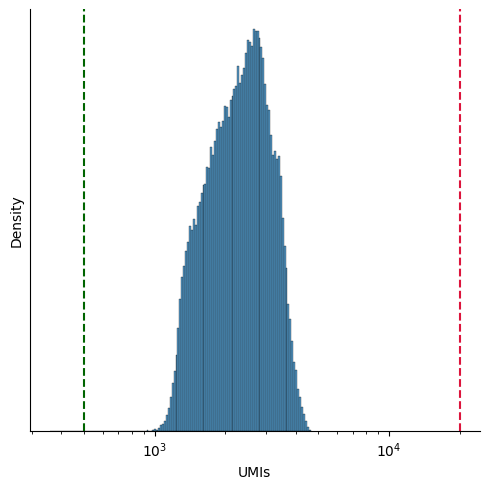

In [10]:
# excluding low and high umi cells

# just using these as default since most datasets already went through qc
# change as needed based on umi distribution
PROPERLY_SAMPLED_MIN_CELL_TOTAL = 500
PROPERLY_SAMPLED_MAX_CELL_TOTAL = 20000

total_umis_per_cell = mc.ut.get_o_numpy(full, '__x__', sum=True)
plot = sb.displot(total_umis_per_cell, log_scale=(10, None))
plot.set(xlabel='UMIs', ylabel='Density', yticks=[])

plot.refline(x=PROPERLY_SAMPLED_MIN_CELL_TOTAL, color='darkgreen')
plot.refline(x=PROPERLY_SAMPLED_MAX_CELL_TOTAL, color='crimson')

too_small_cells_count = np.sum(total_umis_per_cell < PROPERLY_SAMPLED_MIN_CELL_TOTAL)
too_large_cells_count = np.sum(total_umis_per_cell > PROPERLY_SAMPLED_MAX_CELL_TOTAL)

total_umis_per_cell = mc.ut.get_o_numpy(full, name='__x__', sum=True)
too_small_cells_percent = 100.0 * too_small_cells_count / full.n_obs
too_large_cells_percent = 100.0 * too_large_cells_count / full.n_obs

print(
    f'Will exclude {too_small_cells_count} ({too_small_cells_percent:.2f}%%) cells'
    f' with less than {PROPERLY_SAMPLED_MIN_CELL_TOTAL} UMIs'
)
print(
    f'Will exclude {too_large_cells_count} ({too_large_cells_percent:.2f}%%) cells'
    f' with more than {PROPERLY_SAMPLED_MAX_CELL_TOTAL} UMIs'
)

In [11]:
# excluding genes by name/pattern
full = full.copy()

mc.pl.exclude_genes(
    full,
    excluded_gene_names=EXCLUDED_GENE_NAMES, 
    excluded_gene_patterns=EXCLUDED_GENE_PATTERNS,
    random_seed=123456,
) 

/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
set hbca.full.var[bursty_lonely_gene]: 0 true (0%) out of 32383 bools
set hbca.full.var[properly_sampled_gene]: 29850 true (92.18%) out of 32383 bools
set hbca.full.var[excluded_gene]: 2548 true (7.868%) out of 32383 bools


Will exclude 0 (0.00%) cells with more than 10.00% excluded gene UMIs


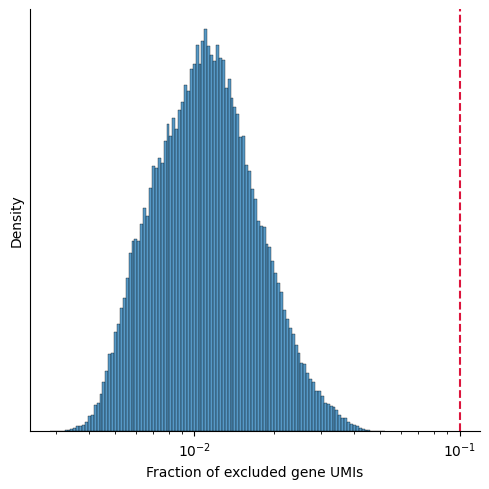

In [12]:
# exclude cells with too high umi for excluded genes (metacell set this at 25%, i'm using 10%)
PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION = 0.1

mc.tl.compute_excluded_gene_umis(full)

excluded_umis_fraction_regularization = 1e-3  # Avoid 0 values in log scale plot.
excluded_umis_per_cell = mc.ut.get_o_numpy(full, 'excluded_umis')
excluded_umis_fraction_per_cell = excluded_umis_per_cell / total_umis_per_cell

excluded_umis_fraction_per_cell += excluded_umis_fraction_regularization
plot = sb.displot(excluded_umis_fraction_per_cell, log_scale=(10, None))
excluded_umis_fraction_per_cell -= excluded_umis_fraction_regularization

plot.set(xlabel='Fraction of excluded gene UMIs', ylabel='Density', yticks=[])
plot.refline(x=PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION, color='crimson')

too_excluded_cells_count = np.sum(
    excluded_umis_fraction_per_cell > PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION
)
too_excluded_cells_fraction = too_excluded_cells_count / len(total_umis_per_cell)

print(
    f'Will exclude {too_excluded_cells_count} ({100 * too_excluded_cells_fraction:.2f}%) cells'
    f' with more than {100 * PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION:.2f}% excluded gene UMIs'
)

In [ ]:
# exclude cells with high umis of excluded genes
# also, exclude doublet cells if there is an obs column indicating them
if full.obs.columns.str.contains('doublet').any():
    print("Excluding doublet cells...")

    doublet_cells_mask = full.obs.filter(regex='doublet')
    doublet_cells_mask = mc.ut.to_numpy_vector(doublet_cells_mask)
    mc.ut.set_o_data(full, 'doublet_cell', doublet_cells_mask)

    mc.pl.exclude_cells(
    full,
    properly_sampled_min_cell_total=PROPERLY_SAMPLED_MIN_CELL_TOTAL,
    properly_sampled_max_cell_total=PROPERLY_SAMPLED_MAX_CELL_TOTAL,
    properly_sampled_max_excluded_genes_fraction=PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION,
    additional_cells_masks=['|doublet_cell']
    )
else:
    print("No known doublet cells")
    
    mc.pl.exclude_cells(
        full,
        properly_sampled_min_cell_total=PROPERLY_SAMPLED_MIN_CELL_TOTAL,
        properly_sampled_max_cell_total=PROPERLY_SAMPLED_MAX_CELL_TOTAL,
        properly_sampled_max_excluded_genes_fraction=PROPERLY_SAMPLED_MAX_EXCLUDED_GENES_FRACTION
    )

set hbca.full.obs[properly_sampled_cell]: 117343 true (100%) out of 117346 bools
set hbca.full.obs[excluded_cell]: 3 true (0.002557%) out of 117346 bools


No known doublet cells


In [20]:
# extract clean data
clean = mc.pl.extract_clean_data(full, name=DATASET_NAME + '.clean')
mc.ut.top_level(clean)
print(f'Clean: {clean.n_obs} cells, {clean.n_vars} genes')

/mnt/scratch1/miniconda3/envs/metacell_MA/lib/python3.14/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
set hbca.clean.obs[full_cell_index]: 117343 int32s
set hbca.clean.var[full_gene_index]: 29835 int32s


Clean: 117343 cells, 29835 genes


In [21]:
# filter to necessary obs columns to save space
clean.obs = clean.obs[['cell_type']]
clean

AnnData object with n_obs × n_vars = 117343 × 29835
    obs: 'cell_type'
    var: 'feature_is_filtered', 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'bursty_lonely_gene', 'properly_sampled_gene', 'excluded_gene', 'full_gene_index'
    uns: 'citation', 'default_embedding', 'is_pre_analysis', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', '__name__'
    obsm: 'X_umap'

In [22]:
# write clean data to output
clean.write_h5ad(OUTPUT_DIR + DATASET_NAME + '.clean.h5ad')